In [42]:
# pip install opensmile
# pip install surfboard

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
import opensmile

In [3]:
#import soundfile as sf

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Loading and pre-processing training data

In [4]:
import os
import data_loader_HUMV
import audio_preprocessing

In [ ]:
# Define the root directory where the audio files are stored
root_directory = r'C:\Users\Marcos\Documents\IDIVAL\Proyectos\Audio_Parkinson\Audio_HUMV_enhanced'
start_with=  'pataka' #'vocal'
exact_name =    None #'pataka.wav'

# Load the audio data using the data_loader function
df = data_loader_HUMV.load_audio_data(root_directory, start_with, exact_name)
df.head()

# Patients to drop
patients_to_drop = []

# Drop rows where 'Patient' is in the list of patients_to_drop
df_filtered = df[~df['Patient'].isin(patients_to_drop)]

# Show the first few rows of the loaded DataFrame
df_filtered.head()

Loaded 117 audio files.
Label distribution:
Label
0    50
1    34
2    33
Name: count, dtype: int64


,Patient,Label,File_Path,Audio Name
0,HUMV_HC_1,0,C:\Users\Marcos\Documents\IDIVAL\Proyectos\Aud...,1_HC
1,HUMV_HC_10,0,C:\Users\Marcos\Documents\IDIVAL\Proyectos\Aud...,10_HC
2,HUMV_HC_11,0,C:\Users\Marcos\Documents\IDIVAL\Proyectos\Aud...,11_HC
3,HUMV_HC_12,0,C:\Users\Marcos\Documents\IDIVAL\Proyectos\Aud...,12_HC
4,HUMV_HC_13,0,C:\Users\Marcos\Documents\IDIVAL\Proyectos\Aud...,13_HC


In [6]:
df_filtered.shape

(117, 4)

In [10]:
# Step 1: Filter the rows where the Label is either 0 or 2
df_HC_vs_PD = df_filtered[df_filtered['Label'].isin([0, 2])]

# Step 2: Replace the Label value 2 with 1
df_HC_vs_PD['Label'] = df_HC_vs_PD['Label'].replace(2, 1)

In [11]:
df_HC_vs_PD.shape

(83, 4)

In [12]:
df_HC_vs_PD['Label'].value_counts()

Label
0    50
1    33
Name: count, dtype: int64

In [7]:
#preprocessed_data_np, labels_np = audio_preprocessing.execute_preprocessing(df, start_time = 1, duration = 2, normalize = True)

In [17]:
preprocessed_chunks_data_np, labels_chunks_np, ids_np = audio_preprocessing.execute_preprocess_and_split(df_HC_vs_PD, start_time=0, chunk_duration=5, max_duration = None, target_sr=16000, remove_silence= True, file_path_column='File_Path')

Total chunks generated: 98


In [ ]:
# len preprocessed_chunks_data_np[0] = target sr (16000) x 5 s = 80000 
len(preprocessed_chunks_data_np[0])

80000

In [19]:
# Get unique values and their counts
unique_labels, counts = np.unique(labels_chunks_np, return_counts=True)

# Print unique values and their counts
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} occurrences")

Label 0: 62 occurrences
Label 1: 36 occurrences


In [20]:
len(ids_np), len(labels_chunks_np)

(98, 98)

In [ ]:
# Save the preprocessed data, labels, and patient IDs as .npy files
np.save("audio_segments_vocal.npy", preprocessed_chunks_data_np)
np.save("labels_vocal.npy", labels_chunks_np)
np.save("patient_ids_vocal.npy", ids_np)
print("Arrays saved successfully!")

Arrays saved successfully!


# Extracting features with OpenSmile

In [21]:
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals,
)

In [22]:
# Initialize a list to store features for each chunk
all_chunk_features = []

# Loop through each chunk and process the signal extracting features with OpenSmile
for i, chunk in tqdm(enumerate(preprocessed_chunks_data_np), total=len(preprocessed_chunks_data_np), desc="Processing chunks"):
    # Extract features for the current chunk
    features = smile.process_signal(chunk, sampling_rate=16000)
    
    # Convert the features (if not already a DataFrame) and append to the list
    if not isinstance(features, pd.DataFrame):
        features = pd.DataFrame(features)
    
    all_chunk_features.append(features)

# Combine all chunk features into a single DataFrame
training_features_df = pd.concat(all_chunk_features, ignore_index=True)


Processing chunks:   0%|          | 0/98 [00:00<?, ?it/s]

Processing chunks: 100%|██████████| 98/98 [00:07<00:00, 13.29it/s]


In [23]:
training_features_df.shape

(98, 6373)

In [ ]:
# Save the combined features DataFrame to a CSV file
training_features_df.to_csv("opensmile_features_pataka.csv", index=False)

In [24]:
training_features_df['Label'] = labels_chunks_np
training_features_df['Id'] = ids_np

In [26]:
training_features_df.head(5)

,audspec_lengthL1norm_sma_range,audspec_lengthL1norm_sma_maxPos,audspec_lengthL1norm_sma_minPos,audspec_lengthL1norm_sma_quartile1,audspec_lengthL1norm_sma_quartile2,audspec_lengthL1norm_sma_quartile3,audspec_lengthL1norm_sma_iqr1-2,audspec_lengthL1norm_sma_iqr2-3,audspec_lengthL1norm_sma_iqr1-3,audspec_lengthL1norm_sma_percentile1.0,...,mfcc_sma_de[14]_peakMeanAbs,mfcc_sma_de[14]_peakMeanMeanDist,mfcc_sma_de[14]_peakMeanRel,mfcc_sma_de[14]_minRangeRel,mfcc_sma_de[14]_meanRisingSlope,mfcc_sma_de[14]_stddevRisingSlope,mfcc_sma_de[14]_meanFallingSlope,mfcc_sma_de[14]_stddevFallingSlope,Label,Id
0,3.592314,0.105477,0.000000,0.182767,0.644505,1.390027,0.461738,0.745522,1.207260,0.028190,...,2.716678,2.703471,19.891354,0.441327,133.497971,73.819313,112.924080,58.729927,0,HUMV_HC_1
1,4.400823,0.766734,0.030426,0.603273,1.286983,2.069480,0.683710,0.782497,1.466207,0.182934,...,2.344104,2.369686,-19.243359,0.472107,113.318077,65.573792,115.380562,60.229786,0,HUMV_HC_10
2,2.810560,0.653144,0.914807,0.189187,0.744373,1.837923,0.555186,1.093551,1.648736,0.007722,...,2.117560,2.103646,19.754143,0.420634,102.214119,58.927959,78.777420,49.337601,0,HUMV_HC_11
3,3.676471,0.060852,0.590264,0.224010,0.525390,1.153764,0.301381,0.628374,0.929755,0.060290,...,2.082910,2.057034,19.035294,0.536834,101.698738,48.214745,85.884979,44.089146,0,HUMV_HC_12
4,3.078957,0.279919,0.000000,0.199617,0.920869,1.673735,0.721253,0.752865,1.474118,0.050689,...,2.114478,2.154722,-18.074734,0.460292,99.320419,52.905651,103.044044,48.519421,0,HUMV_HC_13


In [20]:
training_features_df.to_csv("TF_vocal_audio.csv", header = True, index = False)

In [27]:
# Check for NaN values in the entire DataFrame
nan_summary = training_features_df.isna().sum()

if len(nan_summary[nan_summary > 0]) > 0:
    # Print the columns that have missing values along with the count
    print("Columns with missing values and the count of NaNs in each column:")
    print(nan_summary[nan_summary > 0])
else:
    print("There are no columns with missing values")

There are no columns with missing values


####  Imputation (If necessary)

In [20]:
#df_imputed = utils.imputation(training_features_df, 0.5)

# Defining X and y

In [28]:
X = training_features_df.drop(['Label', 'Id'], axis=1)
y = training_features_df['Label']

In [29]:
X.shape, y.shape

((98, 6373), (98,))

In [30]:
y.unique()

array([0, 1])

In [28]:
# X_test= test_features_df.drop('Label', axis=1)
# y_test = test_features_df['Label']

# Feature selection

## LASSO

In [31]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Initialize LASSO model for feature selection
lasso = Lasso(alpha=0.01)  # Adjust alpha as needed
lasso.fit(X, y)


# Select the important features based on the LASSO model
model = SelectFromModel(lasso, prefit=True)
X_train_selected = model.transform(X)

# Get a boolean mask of the selected features
selected_features_mask = model.get_support()

# Get the names of the selected columns
selected_columns = X.columns[selected_features_mask]

# Print the names of the selected columns
print("Selected Features:")
print(selected_columns)



Selected Features:
Index(['audSpec_Rfilt_sma[5]_range', 'audSpec_Rfilt_sma[6]_kurtosis',
       'audSpec_Rfilt_sma[7]_range', 'audSpec_Rfilt_sma[7]_kurtosis',
       'audSpec_Rfilt_sma[9]_range', 'audSpec_Rfilt_sma[9]_lpgain',
       'audSpec_Rfilt_sma[10]_range', 'audSpec_Rfilt_sma[10]_lpgain',
       'audSpec_Rfilt_sma[11]_range', 'audSpec_Rfilt_sma[15]_range',
       ...
       'pcm_fftMag_spectralCentroid_sma_de_peakRangeAbs',
       'pcm_fftMag_spectralCentroid_sma_de_meanRisingSlope',
       'pcm_fftMag_spectralCentroid_sma_de_stddevRisingSlope',
       'pcm_fftMag_spectralCentroid_sma_de_meanFallingSlope',
       'pcm_fftMag_spectralCentroid_sma_de_stddevFallingSlope',
       'pcm_fftMag_spectralKurtosis_sma_de_peakRangeAbs',
       'pcm_fftMag_spectralKurtosis_sma_de_peakMeanAbs',
       'pcm_fftMag_spectralKurtosis_sma_de_stddevRisingSlope',
       'pcm_fftMag_spectralKurtosis_sma_de_stddevFallingSlope',
       'mfcc_sma_de[10]_peakMeanRel'],
      dtype='object', length=226)


## ReliefF

In [33]:
pip install skrebate


  Using cached skrebate-0.62.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29267 sha256=5672bc4d33c43db557ad7a4cabc1186482b66f3115f44bf85ebab4dad1ca80ce
  Stored in directory: c:\users\marcos\appdata\local\pip\cache\wheels\f0\04\f4\1a6945c69819f1641bca4871bbec1345f872cdf8e19593e9bf
Successfully built skrebate


  DEPRECATION: Building 'skrebate' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'skrebate'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [34]:
from skrebate import ReliefF

# Initialize ReliefF
relief = ReliefF(n_features_to_select=30, n_neighbors = 100, n_jobs=10)  # Choose the number of top features

# Fit and transform the feature matrix and labels
relief_features = relief.fit_transform(X.values,y.values)

In [35]:
relief.top_features_

array([5263, 1655, 1651, ..., 5350,  551,  681])

In [36]:
# Assuming that X_numeric is your input feature matrix and it's a DataFrame (before converting to NumPy)
# and you have already fit ReliefF
n_features_to_select = 30

# Get the indices of the top features selected by ReliefF
selected_feature_indices = relief.top_features_[:relief.n_features_to_select]

# Get the original feature names from the DataFrame (before conversion to NumPy)
original_feature_names = X.columns  # Assuming X_numeric is a DataFrame before converting to NumPy

# Get the names of the selected features based on the indices
selected_feature_names_Relieff = original_feature_names[selected_feature_indices]

# Print the names of the selected features
print("Selected feature names by ReliefF:")
print(selected_feature_names_Relieff)

Selected feature names by ReliefF:
Index(['mfcc_sma[5]_peakRangeAbs', 'mfcc_sma[5]_stddev', 'mfcc_sma[5]_iqr1-3',
       'pcm_fftMag_fband1000-4000_sma_kurtosis', 'mfcc_sma[1]_centroid',
       'mfcc_sma[5]_meanPeakDist',
       'pcm_fftMag_spectralVariance_sma_stddevRisingSlope', 'mfcc_sma[5]_lpc0',
       'pcm_fftMag_spectralVariance_sma_iqr1-3', 'mfcc_sma[13]_upleveltime75',
       'mfcc_sma_de[2]_range', 'mfcc_sma[5]_pctlrange0-1',
       'pcm_fftMag_fband1000-4000_sma_skewness', 'pcm_zcr_sma_centroid',
       'mfcc_sma[1]_linregc1', 'pcm_fftMag_spectralVariance_sma_de_quartile3',
       'pcm_fftMag_fband250-650_sma_de_lpc0', 'mfcc_sma[5]_range',
       'mfcc_sma_de[5]_lpc0', 'mfcc_sma[5]_iqr2-3',
       'pcm_fftMag_fband1000-4000_sma_de_maxSegLen',
       'pcm_fftMag_spectralRollOff90.0_sma_stddevRisingSlope',
       'pcm_fftMag_spectralCentroid_sma_stddevRisingSlope',
       'pcm_fftMag_spectralVariance_sma_iqr2-3',
       'pcm_fftMag_spectralRollOff90.0_sma_meanRisingSlope',
   

In [21]:
refieff_features_name = ['pcm_RMSenergy_sma_de_meanPeakDist', 'mfcc_sma[9]_peakMeanAbs',
       'mfcc_sma[9]_quartile1', 'mfcc_sma[9]_amean',
       'mfcc_sma[9]_percentile1.0', 'mfcc_sma[9]_quartile2',
       'audSpec_Rfilt_sma_de[1]_quartile3', 'mfcc_sma[9]_quartile3',
       'mfcc_sma[9]_percentile99.0',
       'pcm_fftMag_spectralEntropy_sma_de_meanPeakDist', 'mfcc_sma[7]_lpc2',
       'mfcc_sma[10]_flatness', 'audSpec_Rfilt_sma_de[1]_iqr2-3',
       'audSpec_Rfilt_sma_de[1]_peakDistStddev', 'F0final_sma_ff0_minSegLen',
       'mfcc_sma[10]_quartile3',
       'pcm_fftMag_spectralSlope_sma_de_meanPeakDist',
       'logHNR_sma_percentile1.0', 'mfcc_sma[10]_peakMeanAbs',
       'F0final_sma_ff0_meanSegLen', 'mfcc_sma[10]_quartile2',
       'pcm_fftMag_spectralHarmonicity_sma_de_meanPeakDist',
       'audSpec_Rfilt_sma[1]_percentile1.0', 'mfcc_sma[5]_peakMeanAbs',
       'mfcc_sma[10]_amean', 'pcm_zcr_sma_de_posamean',
       'mfcc_sma[5]_quartile3', 'mfcc_sma[7]_lpc3',
       'pcm_fftMag_spectralEntropy_sma_meanPeakDist',
       'mfcc_sma[7]_percentile1.0']

In [22]:
training_features_df_filtered = training_features_df[refieff_features_name]
training_features_df_filtered['Label'] = labels_chunks_np
training_features_df_filtered['Id'] = ids_np

training_features_df_filtered.to_csv("TF_vocal_audio.csv", header = True, index = False)

In [23]:
training_features_df_filtered.shape

(412, 32)

# ML

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import make_scorer


In [83]:
patient_ids = training_features_df['Id'] # Extract patient IDs from audio IDs

# GroupKFold cross-validator
group_kfold = GroupKFold(n_splits=5)

###  Defining parameter grids for GridSearchCV

In [117]:
params_RF = {
    "n_estimators": np.arange(50, 150, 25),
    "max_depth": np.arange(5, 15, 2),
    "criterion": ["gini", "entropy"],
    "class_weight" : ["balanced"],
    "max_samples" : np.arange(0.1, 1, 0.1),
    "max_features": np.arange(0.1, 1, 0.1),
    

}

scoring = {"AUC": "roc_auc", "F1": "f1", "Specificity": make_scorer(recall_score, pos_label=0), "Accuracy": "accuracy"}

In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


Gaussian = GaussianNB()
DTC = DecisionTreeClassifier(random_state=42)


params_AdaBoost = {
    'estimator': [Gaussian, DTC],
    'n_estimators': np.arange(50, 150, 25),
    'learning_rate': [0.01, 0.1, 0.5, 1.0, 2.0]
}

In [119]:
params_SVC =   [ 
    {'C' : [0.01, 0.1, 1, 10],  'kernel': ['linear'], 'class_weight':['balanced']},
    {'C' : [0.01, 0.1, 1, 10],  'kernel': ['poly'], 'degree': [2,3,4,5,6] , 'gamma': ['scale', 'auto'], 'class_weight':['balanced']},
    {'C' : [0.01, 0.1, 1, 10],  'kernel': ['rbf'], 'gamma': ['scale', 'auto'] , 'class_weight':['balanced']},
    {'C' : [0.01, 0.1, 1, 10],  'kernel': ['sigmoid'], 'gamma': ['scale', 'auto'] , 'class_weight':['balanced']},    
]

### Searching best parameters with GridSearchCV for RF

In [123]:
X_filtered = X[refieff_features_name]

X_filtered.shape

(507, 30)

In [125]:
len(y), len(patient_ids)

(507, 507)

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
X_scaled = pd.DataFrame(X_scaled, columns=X_filtered.columns)
X_scaled.head()

,pcm_RMSenergy_sma_de_meanPeakDist,mfcc_sma[9]_peakMeanAbs,mfcc_sma[9]_quartile1,mfcc_sma[9]_amean,mfcc_sma[9]_percentile1.0,mfcc_sma[9]_quartile2,audSpec_Rfilt_sma_de[1]_quartile3,mfcc_sma[9]_quartile3,mfcc_sma[9]_percentile99.0,pcm_fftMag_spectralEntropy_sma_de_meanPeakDist,...,mfcc_sma[10]_quartile2,pcm_fftMag_spectralHarmonicity_sma_de_meanPeakDist,audSpec_Rfilt_sma[1]_percentile1.0,mfcc_sma[5]_peakMeanAbs,mfcc_sma[10]_amean,pcm_zcr_sma_de_posamean,mfcc_sma[5]_quartile3,mfcc_sma[7]_lpc3,pcm_fftMag_spectralEntropy_sma_meanPeakDist,mfcc_sma[7]_percentile1.0
0,-0.03,-0.12,0.08,0.00,0.40,-0.05,-0.27,-0.09,-0.16,1.14,...,0.46,0.27,0.41,-0.20,0.42,0.21,-0.32,1.14,0.88,0.89
1,-0.16,-0.47,-0.22,-0.35,-0.04,-0.34,-0.59,-0.51,-0.63,0.17,...,0.66,-0.26,0.94,-0.46,0.67,-0.16,-0.42,0.74,0.95,1.01
2,-0.16,-0.07,0.04,-0.04,0.26,-0.06,-0.82,-0.11,-0.23,0.10,...,0.49,-0.31,0.81,-0.62,0.51,-0.41,-0.53,0.71,-0.12,0.86
3,0.26,0.31,0.57,0.46,0.76,0.48,-0.71,0.38,0.06,0.30,...,0.50,-0.25,-0.02,-0.47,0.47,-0.14,-0.43,0.84,0.91,1.20
4,-0.44,0.31,0.60,0.49,0.87,0.46,-0.46,0.35,0.16,-0.02,...,0.27,0.30,-0.00,-0.38,0.26,0.17,-0.35,0.62,1.52,1.42


In [142]:
search_RF = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params_RF,
    n_jobs = -1,
    cv = group_kfold.split(X_filtered, y, patient_ids),
    scoring = scoring,
    refit = "AUC",
    verbose=1,
)

In [143]:
search_RF.fit(X_filtered, y)

Fitting 5 folds for each of 3240 candidates, totalling 16200 fits


GridSearchCV(cv=<generator object _BaseKFold.split at 0x000001CB58D4D890>,
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 5,  7,  9, 11, 13]),
                         'max_features': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'max_samples': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'n_estimators': array([ 50,  75, 100, 125])},
             refit='AUC',
             scoring={'AUC': 'roc_auc', 'Accuracy': 'accuracy', 'F1': 'f1',
                      'Specificity': make_scorer(recall_score, response_method='predict', pos_label=0)},
             verbose=1)

In [144]:
# Print the best parameters and the best score
print("Best parameters found:", search_RF.best_params_)
print("Best specificity score:", search_RF.best_score_)

Best parameters found: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'max_features': 0.1, 'max_samples': 0.1, 'n_estimators': 50}
Best specificity score: 0.6994675127027294


In [145]:
results_RF = pd.DataFrame(search_RF.cv_results_)
results_RF.to_csv('./search_RF_results_gridsearch_vocal_PD_2.csv', index=False)

### Building the RF model with the best parameters 

In [83]:
from sklearn.model_selection import GroupShuffleSplit
# GroupShuffleSplit for an 80/20 train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=2)

In [84]:
X_np = np.array(X_filtered)

# Split the data
train_idx, test_idx = next(gss.split(X_filtered, y, groups=patient_ids))

# Create training and test sets
X_train, X_test = X_np[train_idx], X_np[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [85]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((392, 30), (105, 30), (392,), (105,))

In [106]:
unique, counts = np.unique(y_train, return_counts=True)
dict(zip(unique, counts))

{0: 215, 1: 177}

In [86]:
# Utilizar los mejores parámetros para entrenar un nuevo modelo
best_params = search_RF.best_params_
rf_model = RandomForestClassifier(**best_params)
rf_model

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features=0.1, max_samples=0.5,
                       n_estimators=50)

In [87]:
rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)

0.6666666666666666

In [102]:
y_pred_proba =  rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate Youden's J statistic
j_scores = tpr - fpr

# Find the index of the maximum J statistic
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

# Print the optimal threshold
print(f"Optimal threshold based on ROC curve: {optimal_threshold:.2f}")

Optimal threshold based on ROC curve: 0.43


In [103]:
# Change the threshold
threshold = optimal_threshold
# Convert predicted probabilities into binary predictions based on the new threshold
y_pred = (y_pred_proba >= threshold).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy}')
print(f'Classification Report:\n{report}')

Test Accuracy: 0.7714285714285715
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.68      0.69        40
           1       0.81      0.83      0.82        65

    accuracy                           0.77       105
   macro avg       0.76      0.75      0.76       105
weighted avg       0.77      0.77      0.77       105



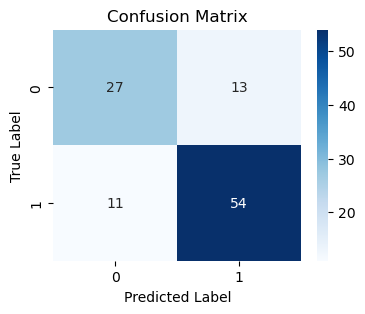

In [104]:
import seaborn as sns
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

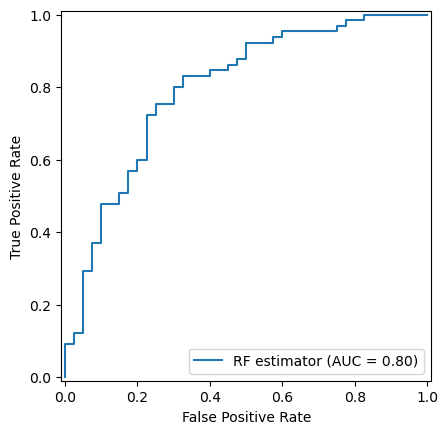

In [105]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='RF estimator')
display.plot()

# CV and analysis of results

In [84]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

In [146]:
#Define the Random Forest classifier with given parameters
clf = RandomForestClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=5,
    max_features=0.1,
    max_samples=0.1,
    n_estimators=50,
    random_state=42 # For reproducibility
)

#{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 13, 'max_features': 0.1, 'max_samples': 0.6, 'n_estimators': 50}

In [157]:
# GroupKFold cross-validator
group_kfold = GroupKFold(n_splits=5)

# Store predictions and true labels for each patient
results = pd.DataFrame({'Id': patient_ids, 'true': y, 'pred': np.nan})

# List to store AUC values for each split
auc_scores = []
roc_curves = []

for fold_idx, (train_index, test_index) in enumerate(group_kfold.split(X_filtered, y, groups=patient_ids)):
    X_train, X_test = X_filtered.iloc[train_index], X_filtered.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    clf.fit(X_train, y_train)
    
#     # Predict on the test set
#     y_pred = clf.predict(X_test)
    # Predict probabilities for the positive class
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    # Convert predicted probabilities into binary predictions based on the new threshold
    y_pred = (y_prob >= 0.5).astype(int)
    
    # Calculate AUC for the current fold
    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves.append((fpr, tpr, fold_idx))
    
    # Store predictions
    results.loc[test_index, 'pred'] = y_pred
    results.loc[test_index, 'prob'] = y_prob
    results.loc[test_index, 'fold'] = fold_idx
    
    # Output AUC for the current fold
    print(f"Fold {fold_idx + 1} AUC: {auc:.3f}")

Fold 1 AUC: 0.740
Fold 2 AUC: 0.851
Fold 3 AUC: 0.395
Fold 4 AUC: 0.683
Fold 5 AUC: 0.732


In [161]:
results.to_csv('./results_CV.csv', index=False)

In [154]:
# Get the unique patient IDs that were in the test set for fold 2
patients_in_fold_2 = results.loc[results['fold'] == 1, 'Id'].unique()  # Fold 2 is indexed as 1

# Get the unique patient IDs that were in the test set for fold 3
patients_in_fold_3 = results.loc[results['fold'] == 2, 'Id'].unique()  # Fold 3 is indexed as 2

# Display the results
print(f"Patients in test during Fold 2: {patients_in_fold_2}")
print(f"Patients in test during Fold 3: {patients_in_fold_3}")


Patients in test during Fold 2: ['vocal_714488' 'vocal_227586' 'vocal_295029' 'vocal_665889'
 'vocal_209769' 'vocal_312893' 'vocal_668327' 'vocal_789630'
 'vocal_604925' 'vocal_724143']
Patients in test during Fold 3: ['vocal_70093' 'vocal_561226' 'vocal_893756' 'vocal_835744' 'vocal_197179'
 'vocal_3010084' 'vocal_226411' 'vocal_648265' 'vocal_738177'
 'vocal_254388']


In [152]:
# Group the results by patient ID
patient_results = results.groupby('Id').apply(lambda x: (x['true'] == x['pred']).mean())

# Classify patients based on the accuracy of their predictions
well_classified = patient_results[patient_results == 1.0].index.tolist()
totally_misdiagnosed = patient_results[patient_results == 0.0].index.tolist()
partially_classified = patient_results[(patient_results > 0.0) & (patient_results < 1.0)].index.tolist()

# Output the results
print(f"Well classified patients: {well_classified}")
print(f"Totally misdiagnosed patients: {totally_misdiagnosed}")
print(f"Partially classified patients: {partially_classified}")

Well classified patients: ['vocal_126396', 'vocal_237004', 'vocal_312893', 'vocal_401816', 'vocal_604925', 'vocal_70093', 'vocal_717094', 'vocal_724143', 'vocal_727638', 'vocal_789630', 'vocal_997408']
Totally misdiagnosed patients: ['vocal_197179', 'vocal_638752', 'vocal_738177', 'vocal_835744']
Partially classified patients: ['vocal_125954', 'vocal_209769', 'vocal_210891', 'vocal_215348', 'vocal_224741', 'vocal_226411', 'vocal_227586', 'vocal_231122', 'vocal_244198', 'vocal_254388', 'vocal_295029', 'vocal_3010084', 'vocal_3178480', 'vocal_507922', 'vocal_561226', 'vocal_625193', 'vocal_635727', 'vocal_648265', 'vocal_648301', 'vocal_654141', 'vocal_665889', 'vocal_667705', 'vocal_668327', 'vocal_681919', 'vocal_686335', 'vocal_689009', 'vocal_714488', 'vocal_714832', 'vocal_71613', 'vocal_72907', 'vocal_791651', 'vocal_804176', 'vocal_815178', 'vocal_824414', 'vocal_893756', 'vocal_936458', 'vocal_98118']


In [155]:
# Filter the results DataFrame for patients in fold 2
fold_2_results = results[results['Id'].isin(patients_in_fold_2)]

# Initialize counters
well_classified = 0
totally_misdiagnosed = 0
partially_classified = 0

# Group by patient ID to check each patient's classification status
for patient_id, group in fold_2_results.groupby('Id'):
    true_labels = group['true'].values
    predicted_labels = group['pred'].values
    
    # Check if all predictions match the true labels
    if (predicted_labels == true_labels).all():
        well_classified += 1
    # Check if all predictions are incorrect
    elif (predicted_labels != true_labels).all():
        totally_misdiagnosed += 1
    # If some predictions are correct and some are incorrect
    else:
        partially_classified += 1

# Output the results
print(f"Number of well classified patients: {well_classified}")
print(f"Number of totally misdiagnosed patients: {totally_misdiagnosed}")
print(f"Number of partially classified patients: {partially_classified}")


Number of well classified patients: 4
Number of totally misdiagnosed patients: 0
Number of partially classified patients: 6


In [156]:
# Filter the results DataFrame for patients in fold 3
fold_3_results = results[results['Id'].isin(patients_in_fold_3)]

# Initialize counters
well_classified = 0
totally_misdiagnosed = 0
partially_classified = 0

# Group by patient ID to check each patient's classification status
for patient_id, group in fold_3_results.groupby('Id'):
    true_labels = group['true'].values
    predicted_labels = group['pred'].values
    
    # Check if all predictions match the true labels
    if (predicted_labels == true_labels).all():
        well_classified += 1
    # Check if all predictions are incorrect
    elif (predicted_labels != true_labels).all():
        totally_misdiagnosed += 1
    # If some predictions are correct and some are incorrect
    else:
        partially_classified += 1

# Output the results
print(f"Number of well classified patients: {well_classified}")
print(f"Number of totally misdiagnosed patients: {totally_misdiagnosed}")
print(f"Number of partially classified patients: {partially_classified}")


Number of well classified patients: 1
Number of totally misdiagnosed patients: 3
Number of partially classified patients: 6


In [153]:
# Aggregate the predictions for each patient
patient_predictions = results.groupby('Id')['pred'].agg(lambda x: (x.sum() >= (len(x) / 2)).astype(int))

# Add the aggregated results back to the results DataFrame
results['final_pred'] = results['Id'].map(patient_predictions)

# Calculate accuracy at the patient level
patient_level_accuracy = (patient_predictions == results.groupby('Id')['true'].first()).mean()

# Output the patient-level accuracy
print(f"Patient-level accuracy: {patient_level_accuracy:.2f}")

# Show an example of patient predictions
print(patient_predictions.head())

Patient-level accuracy: 0.67
Id
vocal_125954    1
vocal_126396    0
vocal_197179    1
vocal_209769    0
vocal_210891    0
Name: pred, dtype: int32


In [135]:
# Calculate the accuracy for each patient
patient_results = results.groupby('Id').apply(lambda x: (x['true'] == x['pred']).mean())

# Compute the mean accuracy across all patients
mean_accuracy = patient_results.mean()
print(f"Mean accuracy across all patients: {mean_accuracy:.2f}")

Mean accuracy across all patients: 0.54


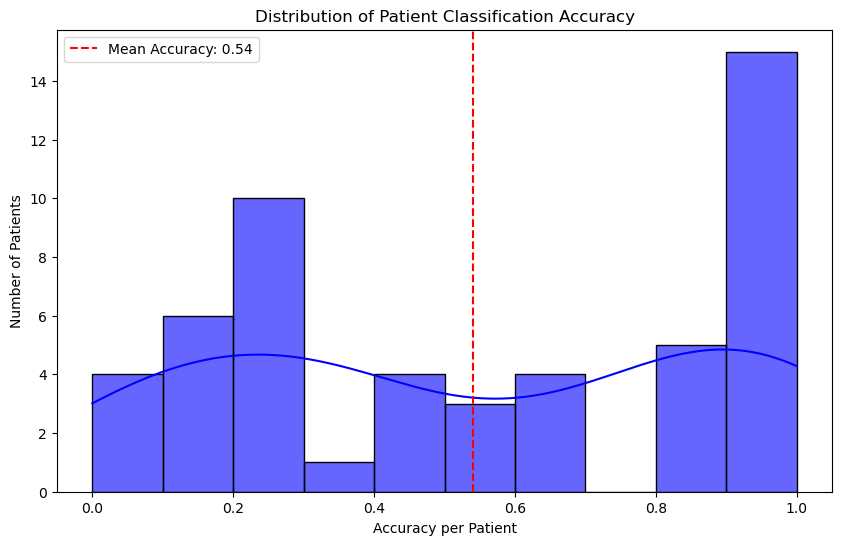

In [136]:
import seaborn as sns
# Set up the figure
plt.figure(figsize=(10, 6))

# Plot the distribution of patient accuracy
sns.histplot(patient_results, bins=10, kde=True, color='blue', alpha=0.6)
plt.axvline(mean_accuracy, color='red', linestyle='--', label=f'Mean Accuracy: {mean_accuracy:.2f}')

# Add labels and title
plt.xlabel('Accuracy per Patient')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patient Classification Accuracy')
plt.legend()

# Show the plot
plt.show()


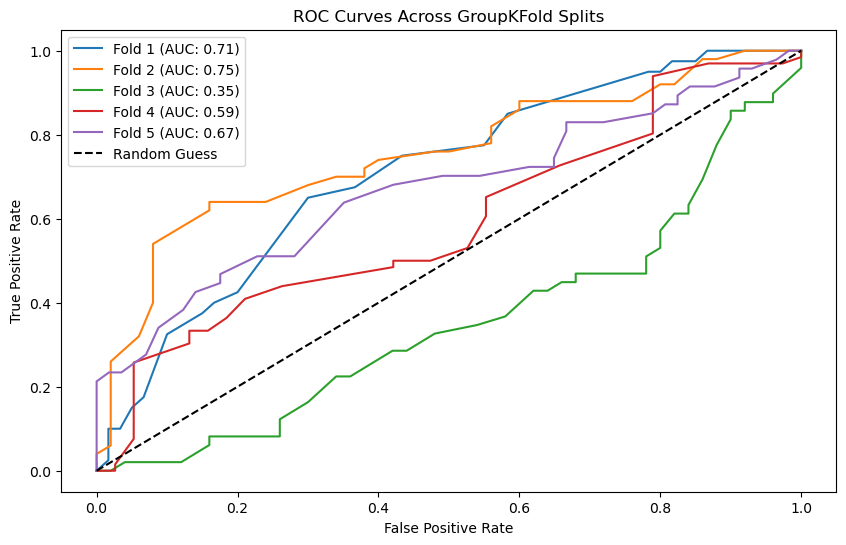

In [137]:
# Set up the figure for ROC curves
plt.figure(figsize=(10, 6))

# Plot ROC curve for each fold
for fpr, tpr, fold_idx in roc_curves:
    plt.plot(fpr, tpr, label=f'Fold {fold_idx + 1} (AUC: {auc_scores[fold_idx]:.2f})')

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Across GroupKFold Splits')
plt.legend()

# Show the plot
plt.show()


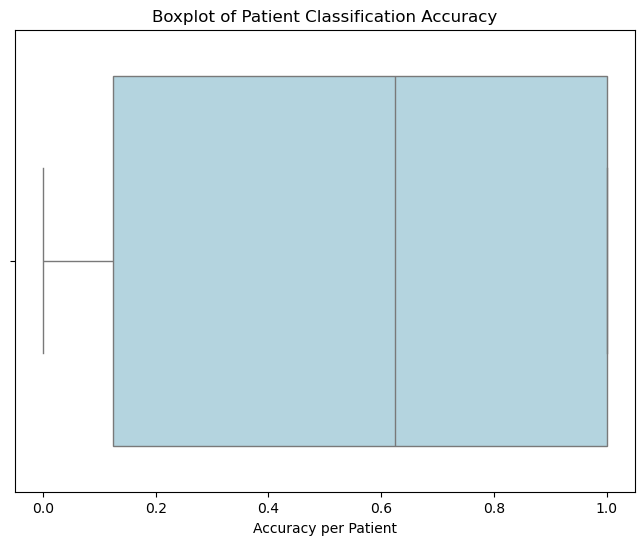

In [41]:
# Set up the figure
plt.figure(figsize=(8, 6))

# Plot a boxplot of patient accuracy
sns.boxplot(x=patient_results, color='lightblue')

# Add labels and title
plt.xlabel('Accuracy per Patient')
plt.title('Boxplot of Patient Classification Accuracy')

# Show the plot
plt.show()